# 1. Filter Specifications & Order Verification

## 1.1 Design Specifications

To achieve a 5th-order Butterworth filter response, the system requirements must enforce a steep attenuation profile within a narrow transition band.

- Passband Edge Frequency $(f_{p}): 1000 Hz$
- Maximum Passband Attenuation $({\alpha }_{\text{max}}): 3 dB (Cutoff frequency f_{c}=f_{p}=1000\text{\ Hz})$
- Stopband Edge Frequency $(f_{s}): 2000 Hz$
- Minimum Stopband Attenuation $({\alpha }_{\text{min}}): 30 dB$


In [11]:
import numpy as np
import scipy as scp
from scipy.signal import butter,buttord
import matplotlib.pyplot as plt
from warnings import filterwarnings
import control.matlab as mt
import control as ct
import scienceplots 

filterwarnings("ignore")
plt.style.use(["science","no-latex"])

In [2]:
Wp=2*np.pi*1e3
Ws=2*np.pi*2e3
gp=3.0
gs=30.0
N,Wn=buttord(Wp,Ws,gp,gs,analog=True)

In [3]:
N

5

In [4]:
Wn

np.float64(6286.1698649592745)

In [5]:
b,a=butter(N,Wn,analog=True)

In [6]:
b

array([9.81590986e+18])

In [7]:
a

array([1.00000000e+00, 2.03424730e+04, 2.06908104e+08, 1.30065949e+12,
       5.05314878e+15, 9.81590986e+18])

In [8]:
sys=mt.tf(b,a)

In [9]:
sys

TransferFunction(
array([9.81590986e+18]),
array([1.00000000e+00, 2.03424730e+04, 2.06908104e+08, 1.30065949e+12,
       5.05314878e+15, 9.81590986e+18]),
outputs=1, inputs=1)

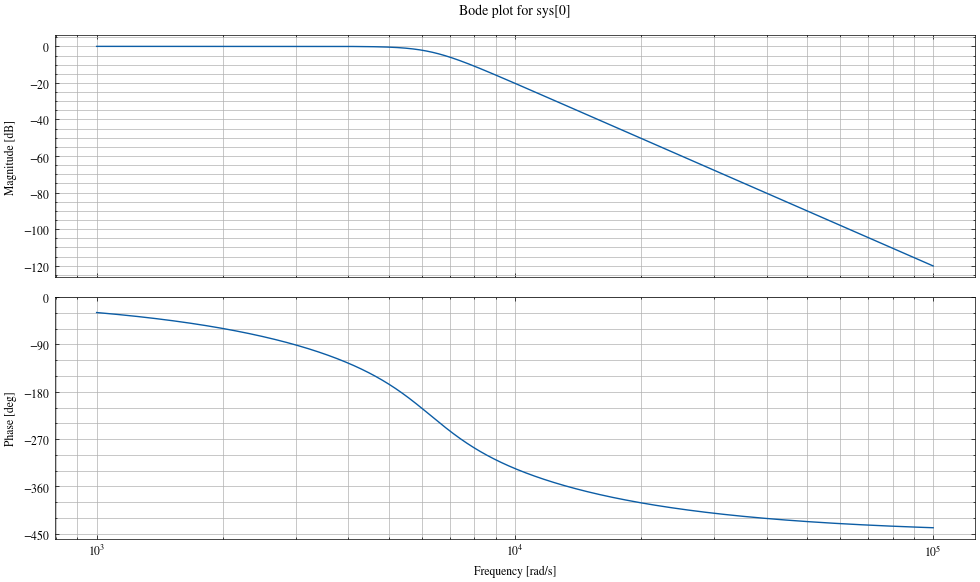

In [13]:
plt.figure(figsize=(1,6))
mag,phase,omega=mt.bode(sys)
plt.show()